In [1]:
import pandas as pd
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

In [2]:
my_df = pd.read_excel("oficial.xlsx", sheet_name="Categórica Codificada")

In [3]:
x = my_df.drop(
    ["Paciente_ID", "Risco de Ataque Cardíaco"],
    axis=1
)

y = my_df["Risco de Ataque Cardíaco"]

In [4]:
x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [5]:
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [6]:
print(y_train.value_counts())

Risco de Ataque Cardíaco
0    1195
1     661
Name: count, dtype: int64


In [7]:
smote = SMOTE(random_state=42)

x_train_bal, y_train_bal = smote.fit_resample(
    x_train,
    y_train
)

In [8]:
print(y_train_bal.value_counts())

Risco de Ataque Cardíaco
0    1195
1    1195
Name: count, dtype: int64


In [9]:
print(x_train.shape)

print(x_train_bal.shape)

(1856, 20)
(2390, 20)


c:\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(



VALIDAÇÃO - DECISION TREE

Accuracy (validação): 0.5352

Classification Report (validação):
              precision    recall  f1-score   support

           0       0.69      0.50      0.58       256
           1       0.40      0.59      0.48       142

    accuracy                           0.54       398
   macro avg       0.54      0.55      0.53       398
weighted avg       0.59      0.54      0.54       398


Matriz de Confusão (validação):
[[129 127]
 [ 58  84]]


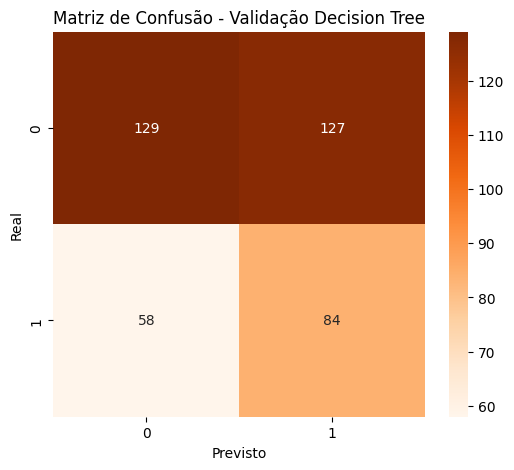


RESULTADOS - DECISION TREE

Accuracy: 0.5503

Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.62      0.64       257
           1       0.38      0.43      0.40       141

    accuracy                           0.55       398
   macro avg       0.52      0.52      0.52       398
weighted avg       0.56      0.55      0.56       398


Matriz de Confusão:
[[159  98]
 [ 81  60]]


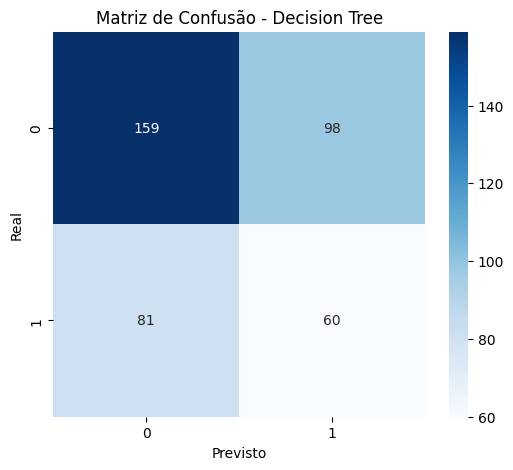


A paciente possui ALTO risco de ataque cardíaco.


In [14]:
# =========================================================
# DECISION TREE
# =========================================================


# =========================================================
# CRIAÇÃO DO MODELO
# =========================================================
# criterion:
# gini -> padrão
# entropy -> ganho de informação

model = DecisionTreeClassifier(

    criterion='gini',
    max_depth=5,
    random_state=42

)

# =========================================================
# TREINAMENTO
# =========================================================

model.fit(x_train_bal, y_train_bal)

# =========================================================
# VALIDAÇÃO
# =========================================================

y_pred_val = model.predict(x_val)

accuracy_val = accuracy_score(y_val, y_pred_val)

print("\n===================================")
print("VALIDAÇÃO - DECISION TREE")
print("===================================")

print(f"\nAccuracy (validação): {accuracy_val:.4f}")

print("\nClassification Report (validação):")
print(classification_report(y_val, y_pred_val))

cm_val = confusion_matrix(y_val, y_pred_val)

print("\nMatriz de Confusão (validação):")
print(cm_val)

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm_val,

    annot=True,
    fmt='d',
    cmap='Oranges'

)

plt.title('Matriz de Confusão - Validação Decision Tree')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

# =========================================================
# PREDIÇÕES - TESTE FINAL
# =========================================================

y_pred = model.predict(x_test)

# =========================================================
# AVALIAÇÃO DO MODELO
# =========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("RESULTADOS - DECISION TREE")
print("===================================")

print(f"\nAccuracy: {accuracy:.4f}")

# =========================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================================================

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

# =========================================================
# MATRIZ DE CONFUSÃO
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de Confusão:")
print(cm)

# =========================================================
# VISUALIZAÇÃO DA MATRIZ
# =========================================================

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.title('Matriz de Confusão - Decision Tree')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

# =========================================================
# EXEMPLO DE NOVA PREVISÃO
# =========================================================
# IMPORTANTE:
# A ordem dos dados deve ser EXATAMENTE
# igual à ordem das colunas do dataset.

nova_paciente = [[

    3,  # Idade
    4,  # Colesterol
    3,  # Pressão Sanguínea
    3,  # Batimentos Cardíacos
    1,  # Diabetes
    0,  # Histórico Familiar
    1,  # Fumante
    0,  # Obesidade
    1,  # Consumo de Álcool
    4,  # Horas de Exercício Semanal
    2,  # Dieta
    1,  # Problemas Cardíacos Anteriores
    0,  # Uso de Medicamentos
    7,  # Nível de Estresse
    5,  # Horas Sedentárias
    3,  # Renda
    4,  # IMC
    3,  # Triglicerídios
    2,  # Dias de Atividade Física
    6   # Horas de Sono

]]

# =========================================================
# PREVISÃO
# =========================================================

previsao = model.predict(nova_paciente)

# =========================================================
# RESULTADO FINAL
# =========================================================

if previsao[0] == 1:

    print("\nA paciente possui ALTO risco de ataque cardíaco.")

else:

    print("\nA paciente possui BAIXO risco de ataque cardíaco.")

In [17]:
# =========================================================
# RESET - rodar antes de cada algoritmo
# =========================================================

x_train_clean, x_temp_clean, y_train_clean, y_temp_clean = train_test_split(
    x, y, test_size=0.30, random_state=42, stratify=y
)

x_val_clean, x_test_clean, y_val_clean, y_test_clean = train_test_split(
    x_temp_clean, y_temp_clean, test_size=0.50, random_state=42, stratify=y_temp_clean
)

smote = SMOTE(random_state=42)
x_train_bal, y_train_bal = smote.fit_resample(x_train_clean, y_train_clean)

c:\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(



VALIDAÇÃO - NAIVE BAYES

Accuracy (validação): 0.5603

Classification Report (validação):
              precision    recall  f1-score   support

           0       0.69      0.57      0.63       256
           1       0.41      0.54      0.46       142

    accuracy                           0.56       398
   macro avg       0.55      0.55      0.55       398
weighted avg       0.59      0.56      0.57       398


Matriz de Confusão (validação):
[[147 109]
 [ 66  76]]


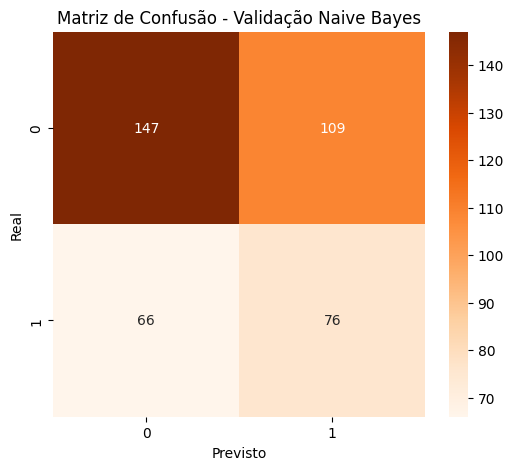


RESULTADOS - NAIVE BAYES

Accuracy: 0.5729

Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.80      0.71       257
           1       0.30      0.16      0.21       141

    accuracy                           0.57       398
   macro avg       0.47      0.48      0.46       398
weighted avg       0.52      0.57      0.53       398


Matriz de Confusão:
[[206  51]
 [119  22]]


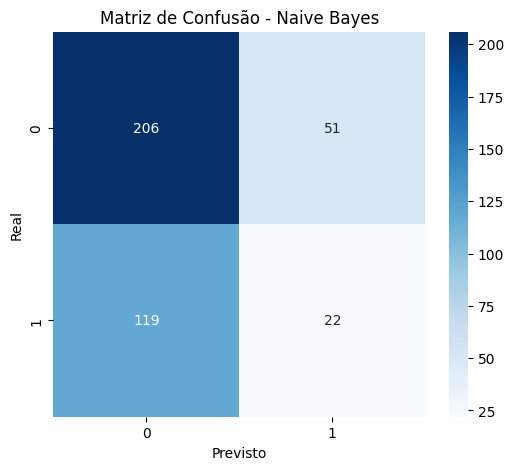


A paciente possui ALTO risco de ataque cardíaco.


c:\WPy64-31241\python-3.12.4.amd64\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [18]:
# =========================================================
# NAIVE BAYES
# =========================================================

# =========================================================
# NORMALIZAÇÃO DOS DADOS
# =========================================================
# GaussianNB funciona melhor com dados normalizados

scaler = StandardScaler()

x_train_bal = scaler.fit_transform(x_train_bal)

x_val = scaler.transform(x_val)

x_test = scaler.transform(x_test)

# =========================================================
# CRIAÇÃO DO MODELO
# =========================================================

model = GaussianNB()

# =========================================================
# TREINAMENTO
# =========================================================

model.fit(x_train_bal, y_train_bal)

# =========================================================
# VALIDAÇÃO
# =========================================================

y_pred_val = model.predict(x_val)

accuracy_val = accuracy_score(y_val, y_pred_val)

print("\n===================================")
print("VALIDAÇÃO - NAIVE BAYES")
print("===================================")

print(f"\nAccuracy (validação): {accuracy_val:.4f}")

print("\nClassification Report (validação):")
print(classification_report(y_val, y_pred_val))

cm_val = confusion_matrix(y_val, y_pred_val)

print("\nMatriz de Confusão (validação):")
print(cm_val)

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm_val,

    annot=True,
    fmt='d',
    cmap='Oranges'

)

plt.title('Matriz de Confusão - Validação Naive Bayes')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

# =========================================================
# PREDIÇÕES - TESTE FINAL
# =========================================================

y_pred = model.predict(x_test)

# =========================================================
# AVALIAÇÃO DO MODELO
# =========================================================

accuracy = accuracy_score(y_test, y_pred)

print("\n===================================")
print("RESULTADOS - NAIVE BAYES")
print("===================================")

print(f"\nAccuracy: {accuracy:.4f}")

# =========================================================
# RELATÓRIO DE CLASSIFICAÇÃO
# =========================================================

print("\nClassification Report:")

print(classification_report(y_test, y_pred))

# =========================================================
# MATRIZ DE CONFUSÃO
# =========================================================

cm = confusion_matrix(y_test, y_pred)

print("\nMatriz de Confusão:")
print(cm)

# =========================================================
# VISUALIZAÇÃO DA MATRIZ
# =========================================================

plt.figure(figsize=(6, 5))

sns.heatmap(

    cm,

    annot=True,
    fmt='d',
    cmap='Blues'

)

plt.title('Matriz de Confusão - Naive Bayes')

plt.xlabel('Previsto')
plt.ylabel('Real')

plt.show()

# =========================================================
# EXEMPLO DE NOVA PREVISÃO
# =========================================================
# IMPORTANTE:
# A ordem deve seguir EXATAMENTE
# a ordem das colunas da base

nova_paciente = [[

    3,  # Idade
    4,  # Colesterol
    3,  # Pressão Sanguínea
    3,  # Batimentos Cardíacos
    1,  # Diabetes
    0,  # Histórico Familiar
    1,  # Fumante
    0,  # Obesidade
    1,  # Consumo de Álcool
    4,  # Horas de Exercício Semanal
    2,  # Dieta
    1,  # Problemas Cardíacos Anteriores
    0,  # Uso de Medicamentos
    7,  # Nível de Estresse
    5,  # Horas Sedentárias
    3,  # Renda
    4,  # IMC
    3,  # Triglicerídios
    2,  # Dias de Atividade Física
    6   # Horas de Sono

]]

# =========================================================
# NORMALIZAR NOVO DADO
# =========================================================

nova_paciente = scaler.transform(nova_paciente)

# =========================================================
# PREVISÃO
# =========================================================

previsao = model.predict(nova_paciente)

# =========================================================
# RESULTADO FINAL
# =========================================================

if previsao[0] == 1:

    print("\nA paciente possui ALTO risco de ataque cardíaco.")

else:

    print("\nA paciente possui BAIXO risco de ataque cardíaco.")